# Proyecto AEMET: Análisis y Modelado

In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import os
import psycopg
from dotenv import load_dotenv

import datetime
from time import sleep
from typing import Any
import requests

from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import lightgbm as lgb




Extracción

In [2]:
# CONFIGURACIÓN Y CREDENCIALES

load_dotenv()
API_KEY = os.environ.get("API_KEY")
POSTGRESQL_URL_KEY = os.environ.get("POSTGRESQL_URL_KEY")


In [ ]:
# INFO

# Borradas pruebas y descargas iniciales.

# Carga histórica completa (YA HECHA — no repetir salvo necesidad)
# df_historico = descarga_historica_completa(años=10)
# df_historico.to_pickle("ALL_10_YEARS.pkl")

# Carga incremental 
# df_nuevo = descarga_incremental()

# Catálogo de estaciones
# df_estaciones, df_metadatos_estaciones = descarga_inventario_estaciones()

# Carga a POSTGRES desde bd.ipynb (se convierten NaN desde aqui) 
# y se guarda df_postgres = pd.read_pickle(r"C:\Users\Kirsay\Desktop\AEMET_proyecto_local\data\df_postgres.pkl")


Añado las definiciones de funciones comprobadas y funcionando y trbajo directamente con los datos de ALL_10_YEARS

* Ejecutar a partir del apartado de exploracion de datos

In [ ]:
# Funcion descarga de datos diariosde todas las estaciones entre fecha_inicio y fecha_fin
# Rango de fechas: la API de AEMET limita a 15 días
# Devuelve (df_datos, df_metadatos, estado_http_aemet).

def datos_todas_estaciones(api_key: str, fecha_inicio: str, fecha_fin: str) -> tuple[pd.DataFrame, pd.DataFrame, Any]:
  
    url = (
        "https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/"
        f"fechaini/{fecha_inicio}/"
        f"fechafin/{fecha_fin}/"
        "todasestaciones"
    )

    respuesta = requests.get(url, params={"api_key": api_key}, timeout=30)
    respuesta.raise_for_status()
    resultado = respuesta.json()

    if resultado.get("estado") != 200:
        raise RuntimeError(f"Error de AEMET: {resultado.get('descripcion')}")

    respuesta_datos = requests.get(resultado["datos"], timeout=30)
    respuesta_metadatos = requests.get(resultado["metadatos"], timeout=30)
    respuesta_datos.raise_for_status()
    respuesta_metadatos.raise_for_status()

    df_datos = pd.DataFrame(respuesta_datos.json())
    df_metadatos = pd.DataFrame(respuesta_metadatos.json())

    return df_datos, df_metadatos, resultado.get("estado")

In [ ]:
# DESCARGA HISTÓRICA INICIAL
# Descarga los últimos 10 años en tramos de 15 días. 
# Guarda LAST_UPDATE.txt con la fecha del ultimo dato descargado


def descarga_historica_completa(años: int = 10, pausa_segundos: int = 15) -> pd.DataFrame:
    
    fecha_inicial = (
        (pd.Timestamp.now() - pd.Timedelta(weeks=52 * años))
        .normalize()
        .strftime("%Y-%m-%dT%H:%M:%SUTC")
    )

    df_datos = pd.DataFrame()
    tramos = (52 * años * 7) // 15  # nº aproximado de bloques de 15 días

    for i in range(tramos):
        fecha_ini_pd = pd.to_datetime(fecha_inicial)
        fecha_ini_xi = fecha_ini_pd + pd.Timedelta(days=15 * i)
        fecha_fin_xi = fecha_ini_pd + pd.Timedelta(days=15 + 15 * i)

        fecha_ini_str = fecha_ini_xi.strftime("%Y-%m-%dT%H:%M:%SUTC")
        fecha_fin_str = fecha_fin_xi.strftime("%Y-%m-%dT%H:%M:%SUTC")

        respuesta = datos_todas_estaciones(API_KEY, fecha_ini_str, fecha_fin_str)
        df_datos = pd.concat([df_datos, respuesta[0]], ignore_index=True)

        print(f"[{i+1}/{tramos}] AEMET estado {respuesta[2]}: "
              f"{fecha_ini_str[:-12]} -> {fecha_fin_str[:-12]}")
        sleep(pausa_segundos)

    
    with open("LAST_UPDATE.txt", "w", encoding="utf-8") as f:
        f.write(f"{df_datos['fecha'].iloc[-1]}")

    return df_datos

In [ ]:
# Descarga incremental desde LAST_UPDATE.txt (Base de la lambda)
# Lee LAST_UPDATE.txt
# Calcula cuántos días faltan hasta hoy (margen de 7 días -> AEMET tarda en subir los datos)
# Descarga día a día 
# Actualiza LAST_UPDATE.txt

def descarga_incremental() -> pd.DataFrame:
    
    with open("LAST_UPDATE.txt", "r", encoding="utf-8") as f:
        last_update = datetime.datetime.strptime(f.read(), "%Y-%m-%d") + datetime.timedelta(days=1)

    dias_pendientes = (datetime.datetime.now() - last_update).days
    df_datos = pd.DataFrame()

    for i in range(max(0, dias_pendientes - 7)):
        fecha_ini_xi = last_update + pd.Timedelta(days=i)
        fecha_fin_xi = last_update + pd.Timedelta(days=i + 1)

        fecha_ini_str = fecha_ini_xi.strftime("%Y-%m-%dT%H:%M:%SUTC")
        fecha_fin_str = fecha_fin_xi.strftime("%Y-%m-%dT%H:%M:%SUTC")

        respuesta = datos_todas_estaciones(API_KEY, fecha_ini_str, fecha_fin_str)
        df_datos = pd.concat([df_datos, respuesta[0]], ignore_index=True)

        print(f"[{i+1}/{max(0, dias_pendientes - 7)}] AEMET estado {respuesta[2]}: "
              f"{fecha_ini_str[:-12]} -> {fecha_fin_str[:-12]}")
        sleep(3)

    if not df_datos.empty:
        with open("LAST_UPDATE.txt", "w", encoding="utf-8") as f:
            f.write(f"{df_datos['fecha'].iloc[-1]}")

    return df_datos

In [ ]:
# Datos todas estaciones (listado y metadatos -> nombre, lat/lon, altitud)

def descarga_inventario_estaciones() -> tuple[pd.DataFrame, pd.DataFrame]:
    
    url = "https://opendata.aemet.es/opendata/api/valores/climatologicos/inventarioestaciones/todasestaciones"

    respuesta = requests.get(url, params={"api_key": API_KEY}, timeout=30)
    respuesta.raise_for_status()
    resultado = respuesta.json()

    if resultado.get("estado") != 200:
        raise RuntimeError(f"Error de AEMET: {resultado.get('descripcion')}")

    respuesta_datos = requests.get(resultado["datos"], timeout=30)
    respuesta_metadatos = requests.get(resultado["metadatos"], timeout=30)
    respuesta_datos.raise_for_status()
    respuesta_metadatos.raise_for_status()

    df_estaciones = pd.DataFrame(respuesta_datos.json())
    df_metadatos = pd.DataFrame(respuesta_metadatos.json())
    df_metadatos = (
        pd.DataFrame(df_metadatos["campos"].tolist())
        .set_index("id")[["descripcion", "tipo_datos", "requerido"]]
        .T
    )

    return df_estaciones, df_metadatos

# Exploración inicial. Estadísticas básicas

In [ ]:
# Carga de datos
df = pd.read_pickle(r"C:\Users\Kirsay\Desktop\AEMET_proyecto_local\data\ALL_10_YEARS")

In [4]:
print(df.shape)

(3042393, 27)


In [4]:
print(df.dtypes)

fecha          str
indicativo     str
nombre         str
provincia      str
altitud        str
tmed           str
prec           str
tmin           str
horatmin       str
tmax           str
horatmax       str
hrMedia        str
hrMax          str
horaHrMax      str
hrMin          str
horaHrMin      str
pintMax        str
dir            str
velmedia       str
racha          str
horaracha      str
presMax        str
horaPresMax    str
presMin        str
horaPresMin    str
sol            str
horaPIntMax    str
dtype: object


In [5]:
df.head(5)

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,dir,velmedia,racha,horaracha,presMax,horaPresMax,presMin,horaPresMin,sol,horaPIntMax
0,2016-08-08,7250C,ABANILLA,MURCIA,174,"25,0","0,0","17,3",04:22,"32,7",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-08-08,0255B,SANTA SUSANNA,BARCELONA,40,"22,9","0,0","16,2",02:50,"29,6",...,22,"1,9","8,6",13:10,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-08-08,5612B,LA RODA DE ANDALUCÍA,SEVILLA,410,"26,4","0,0","19,5",05:40,"33,2",...,18,"5,3","14,2",16:20,"973,5",08,"970,3",18,NaN,NaN
3,2016-08-08,2885K,FRESNO DE SAYAGO,ZAMORA,804,"25,8","0,0","15,7",05:13,"36,0",...,05,"4,4","11,7",08:40,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-08-08,8492X,ATZENETA DEL MAESTRAT,CASTELLON,420,"24,5","0,0","14,7",05:09,"34,3",...,19,"2,8","8,9",15:10,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['fecha', 'indicativo', 'nombre', 'provincia', 'altitud', 'tmed', 'prec',
       'tmin', 'horatmin', 'tmax', 'horatmax', 'hrMedia', 'hrMax', 'horaHrMax',
       'hrMin', 'horaHrMin', 'pintMax', 'dir', 'velmedia', 'racha',
       'horaracha', 'presMax', 'horaPresMax', 'presMin', 'horaPresMin', 'sol',
       'horaPIntMax'],
      dtype='str')

Exploramos el df y encontramos:

- Todas las columnas aparecen como str. -> Corregir tipos.
- Los decimales usan coma en vez de punto. -> Pasar a float.
- Fecha -> a datetime.



In [3]:
# Fecha a datetime
df["fecha"] = pd.to_datetime(df["fecha"])

In [4]:
# Columnas numéricas con coma decimal -> convertir a float
cols_numericas = ["tmed", "prec", "tmin", "tmax", "pintMax", "velmedia", "racha", "presMax", "presMin", "sol"]



El codigo falla al tratar de convertir la columna prec. 

Exploramos buscando valores raros. 

In [5]:
for col in cols_numericas:
    valores_raros = df[col][~df[col].str.replace(",", ".", regex=False).str.match(r"^-?\d+\.?\d*$", na=True)]
    print(col, valores_raros.unique()[:10])

tmed <StringArray>
[]
Length: 0, dtype: str
prec <StringArray>
['Ip', 'Acum']
Length: 2, dtype: str
tmin <StringArray>
[]
Length: 0, dtype: str
tmax <StringArray>
[]
Length: 0, dtype: str
pintMax <StringArray>
[]
Length: 0, dtype: str
velmedia <StringArray>
[]
Length: 0, dtype: str
racha <StringArray>
[]
Length: 0, dtype: str
presMax <StringArray>
[]
Length: 0, dtype: str
presMin <StringArray>
[]
Length: 0, dtype: str
sol <StringArray>
[]
Length: 0, dtype: str


* 'Ip' es un código de AEMET que aparece en la columna de precipitaciones y significa inapreciable. Se registró lluvia por debajo del umbral medible (menos de 0,1 mm). 

En lugar de tratarlo como un NaN consideraremos que el valor es 0.001 (prácticamente no llovió).

* 'Acum' significa que la precipitación de ese día no se pudo reportar y se registra en un día posterior sumando varios días juntos. 

In [8]:
df["altitud"].unique()[:10]

<StringArray>
['174', '40', '410', '804', '420', '1107', '305', '586', '1027', '88']
Length: 10, dtype: str

In [6]:

cols_numericas = ["altitud","hrMedia","hrMax","hrMin","dir","horaPresMax","horaPresMin"]
df[cols_numericas] = df[cols_numericas].apply(pd.to_numeric, errors="coerce")

df["prec"] = df["prec"].replace("Ip", "0.001")
df["prec"] = df["prec"].replace("Acum", np.nan)

cols_float = ["tmed","prec","tmin", "tmax",  "pintMax", "velmedia", "racha", "presMax", "presMin", "sol"]

for col in cols_float:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

cols_hora=["horatmin","horatmax","horaHrMax","horaHrMin", "horaracha","horaPIntMax"]

for col in cols_hora:
    df[col] = df[col].str.strip().str.split(":").str[0]
    df[col] = pd.to_numeric(df[col], errors="coerce")


Análisis de NaNs

In [7]:
# Cuántos nulos hay
df.isna().sum()

fecha                0
indicativo           0
nombre               0
provincia            0
altitud              0
tmed             60831
prec             87267
tmin             59945
horatmin        242387
tmax             59057
horatmax        135256
hrMedia         102466
hrMax           142107
horaHrMax      1122197
hrMin           141807
horaHrMin       425284
pintMax         119639
dir             544574
velmedia        534240
racha           544518
horaracha       694690
presMax        2269393
horaPresMax    2432715
presMin        2269409
horaPresMin    2364104
sol            2510690
horaPIntMax    2462525
dtype: int64

Encontramos una cantidad de valores nulos exagerada en las columnas:
sol, horaPresMin, presMin, presMax, horaPresMax y horaPIntMax; y una cantidad, no tan elevada pero tambien muy alta en: horaracha, dir, racha, velmedia y horaHrMax

Las columnas fecha, indicativo, nombre, provincia y altitud no contienen nulos.

Tratamos de comprobar la hipótesis de que haya estaciones sin sensores para estos datos, o con datos a partir de ciertas fechas (cuando se instalara el sensor).

In [8]:
(df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)

sol            82.52
horaPIntMax    80.94
horaPresMax    79.96
horaPresMin    77.71
presMin        74.59
presMax        74.59
horaHrMax      36.89
horaracha      22.83
dir            17.90
racha          17.90
velmedia       17.56
horaHrMin      13.98
horatmin        7.97
hrMax           4.67
hrMin           4.66
horatmax        4.45
pintMax         3.93
hrMedia         3.37
prec            2.87
tmed            2.00
tmin            1.97
tmax            1.94
altitud         0.00
fecha           0.00
provincia       0.00
indicativo      0.00
nombre          0.00
dtype: float64

In [9]:
# Comprobación: El nulo depende de la estación?
df.groupby("indicativo")["presMax"].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

indicativo
C939T    1.0
C928I    1.0
0009X    1.0
C925F    1.0
0016B    1.0
        ... 
B278     0.0
3013     0.0
8178D    0.0
7145X    0.0
1082     0.0
Name: presMax, Length: 894, dtype: float64

In [10]:

nulos_presMax_estacion = df.groupby("indicativo")["presMax"].apply(lambda x: x.isna().mean())
nulos_sol_estacion = df.groupby("indicativo")["sol"].apply(lambda x: x.isna().mean())

In [11]:
nulos_presMax_estacion.describe()

count    894.000000
mean       0.735383
std        0.428873
min        0.000000
25%        0.145634
50%        1.000000
75%        1.000000
max        1.000000
Name: presMax, dtype: float64

In [15]:
# Estaciones que nunca miden presión
(nulos_presMax_estacion == 1.0).sum()

np.int64(615)

In [16]:
# Estaciones que siempre miden presión
(nulos_presMax_estacion == 0.0).sum()


np.int64(15)

In [17]:
# Estaciones con NaNs variables
(~nulos_presMax_estacion.isin([0.0, 1.0])).sum()

np.int64(264)

In [18]:
# Igual para los valores de sol
nulos_sol_estacion.describe()
(nulos_sol_estacion == 1.0).sum()
(nulos_sol_estacion == 0.0).sum()
(~nulos_sol_estacion.isin([0.0, 1.0])).sum()

np.int64(156)

Comprobamos las fechas de los valores nulos para ver si se concentran o aparecen dispersos como fallos puntuales. 

In [12]:
estaciones_intermedias = nulos_presMax_estacion[~nulos_presMax_estacion.isin([0.0, 1.0])].index
ejemplo = estaciones_intermedias[0]

df[df["indicativo"] == ejemplo].groupby(df["fecha"].dt.year)["presMax"].apply(lambda x: x.isna().mean())
# Muestra año a año el porcentaje de nulos de esa estación de ejemplo

fecha
2016    1.000000
2017    1.000000
2018    1.000000
2019    1.000000
2020    1.000000
2021    1.000000
2026    0.043478
Name: presMax, dtype: float64

In [13]:
#Dado el porcentaje de datos faltantes en estas columnas decidimos no utilizarlas para el entrenamiento

cols_nulos = ["presMax","horaPresMax", "presMin","horaPresMin", "sol", "dir", "velmedia", "racha", "horaracha"]



In [14]:
# df final con las columnas que vamos a usar para el modelo.
# Se guardará en un pickle en localpara no tener que repetir limpieza.

cols_nulos = ["presMax", "horaPresMax", "presMin","horaPresMin", "sol","dir", "velmedia", "racha", "horaracha"]

df_limpio = df.drop(columns=cols_nulos)

# Para análisis/modelado local)
df_limpio = df_limpio.dropna(subset=["tmed", "tmin", "tmax", "prec"])

In [15]:
# Para postgres (con None en lugar de NaN)
df_postgres = df_limpio.astype(object).where(pd.notna(df_limpio), None)

In [16]:
print((df_limpio["tmed"] <= 0).sum())

18678


Outliers

In [17]:
# Buscamos y eliminamos posibles valores erroneos.

error_sensor = df_limpio[(df_limpio["tmax"] < df_limpio["tmin"]) | 
(df_limpio["tmed"] > df_limpio["tmax"]) | 
(df_limpio["tmed"] < df_limpio["tmin"])]
print(f"Errores de sensor: {len(error_sensor)}")



Errores de sensor: 1


In [18]:
# Solo aparece 1, la eliminamos
df_limpio = df_limpio.drop(index=error_sensor.index)

In [ ]:
# NO EJECUTAR
# Guardamospickle (datos limpios en local)
df_limpio.to_pickle("df_limpio_10_years.pkl")

In [ ]:
# NO EJECUTAR
# # Guardamos version para postgres (con None en lugar de NaN)
df_postgres = df_limpio.astype(object).where(pd.notna(df_limpio), None)

# Y los guardamos en un archivo "df_postgres.pkl" al que llamaremos desde bd.ipynb
# Donde tenemos definida la funcion "cargar_a_postgres"
df_postgres.to_pickle("df_postgres.pkl")


Analizamos correlacion y graficamos para ver distribucion

In [26]:
# Correlación (Spearman) con tª media
corr = df_limpio.corr(numeric_only=True, method="spearman")
print(corr["tmed"].sort_values(ascending=False))

tmed           1.000000
tmax           0.957504
tmin           0.941881
horaPIntMax    0.066883
horatmax       0.058537
horaHrMin      0.025740
horaHrMax     -0.114339
horatmin      -0.191684
pintMax       -0.264611
prec          -0.274488
altitud       -0.301836
hrMin         -0.425445
hrMax         -0.451892
hrMedia       -0.486112
Name: tmed, dtype: float64


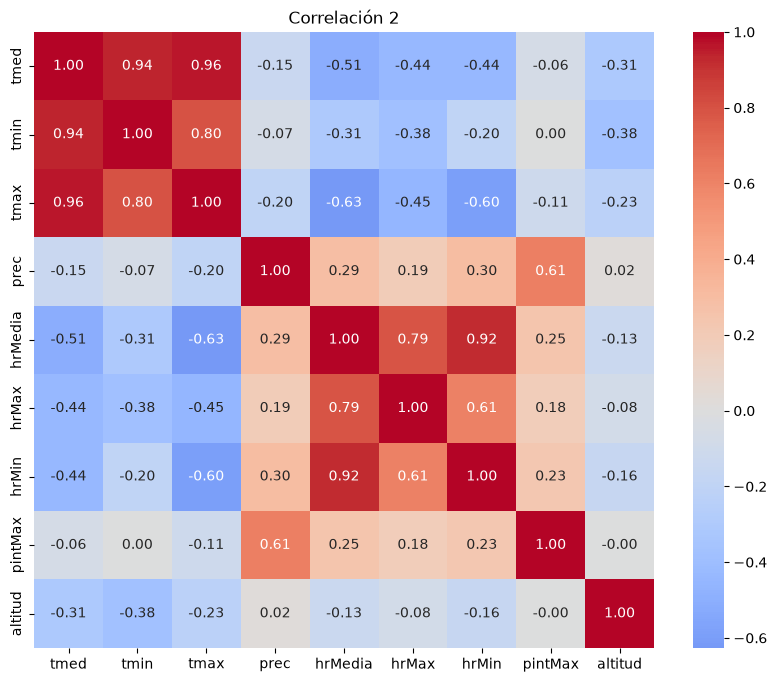

In [39]:
# Heatmap

cols_heatmap = ["tmed", "tmin", "tmax", "prec","hrMedia", "hrMax", "hrMin","pintMax", "altitud"]

corr_2 = df_limpio[cols_heatmap].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_2, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación 2")
plt.show()

Correlaciones negativas a tener en cuenta -> Rebajan la temperatura

* Humedad relativa (-0.48 de media)
* Altitud (-0.30)
* Precipitaciones (-0.27)

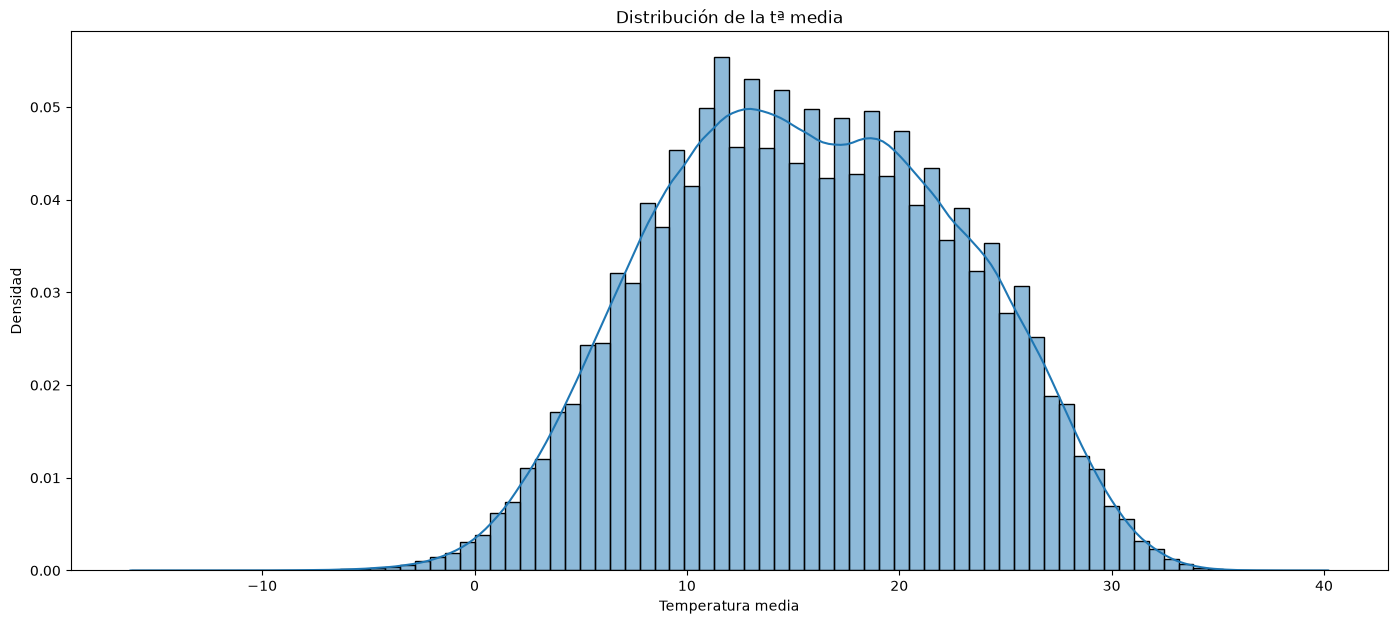

In [40]:
# Distribución de la temperatura media 
plt.figure(figsize=(17, 7))
sns.histplot(data=df_limpio, x="tmed", bins=80, kde=True, stat="density")
plt.title("Distribución de la tª media")
plt.xlabel("Temperatura media")
plt.ylabel("Densidad")
plt.show()

Distribución bastante simétrica, normal (campana).
Con valores entre -8°C y 35°C y ligera diferenciacion en los picos entre los valores de invierno y verano.

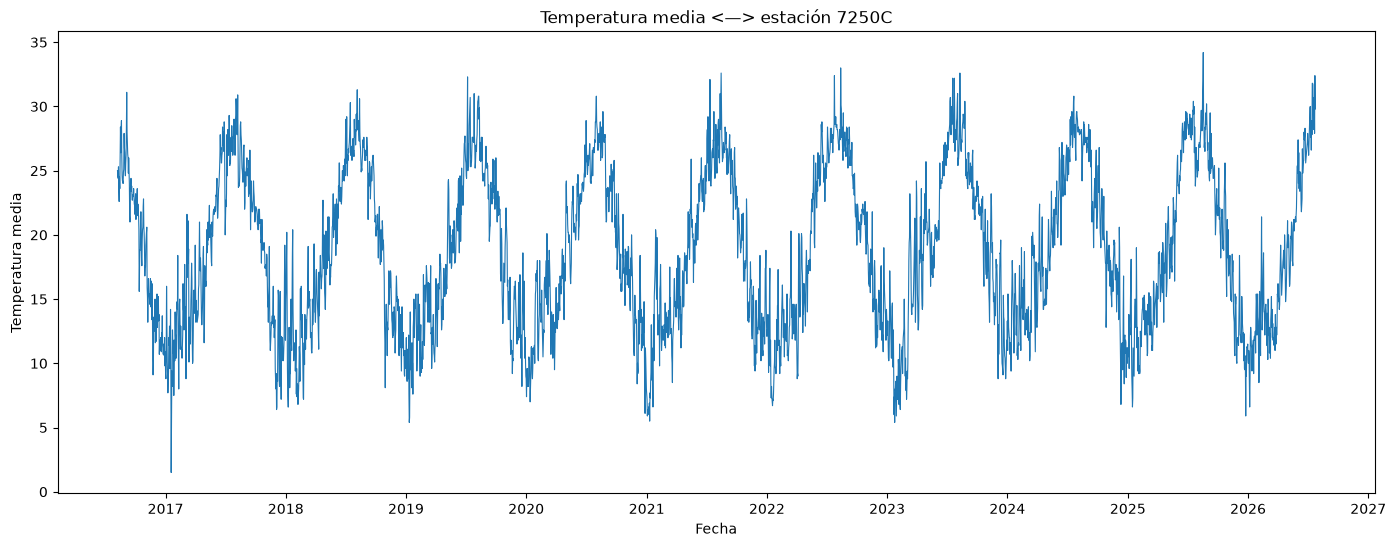

In [42]:
# Para visualizar el patron de estaciones (verano/invierno)
estac_prueba = "7250C"  

patron = df_limpio[df_limpio["indicativo"] == estac_prueba].sort_values("fecha")

plt.figure(figsize=(17, 6))
plt.plot(patron["fecha"], patron["tmed"], linewidth=0.8)
plt.title(f"Temperatura media <—> estación {estac_prueba}")
plt.xlabel("Fecha")
plt.ylabel("Temperatura media")
plt.show()

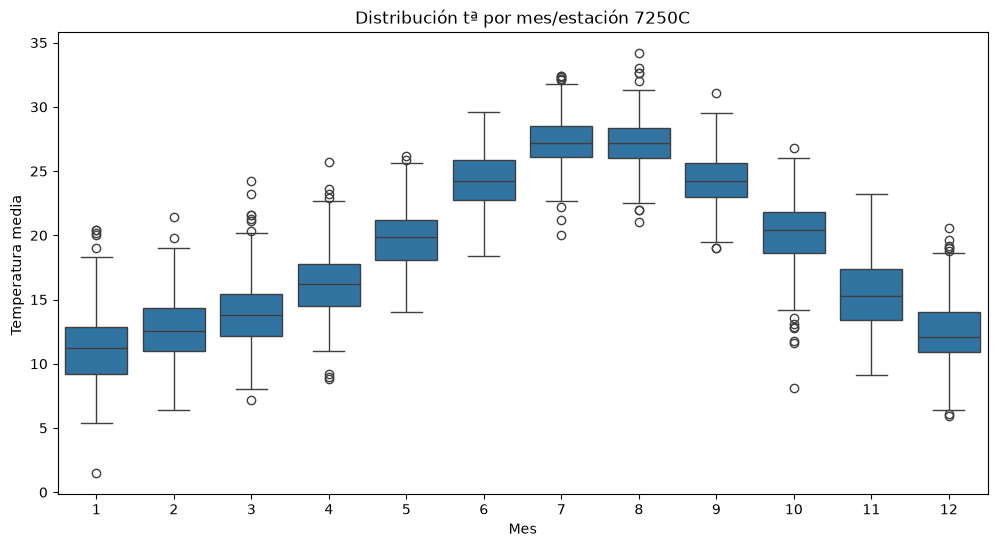

In [43]:
patron["mes"] = patron["fecha"].dt.month

plt.figure(figsize=(12, 6))
sns.boxplot(data=patron, x="mes", y="tmed")
plt.title(f"Distribución tª por mes/estación {estac_prueba}")
plt.xlabel("Mes")
plt.ylabel("Temperatura media ")
plt.show()

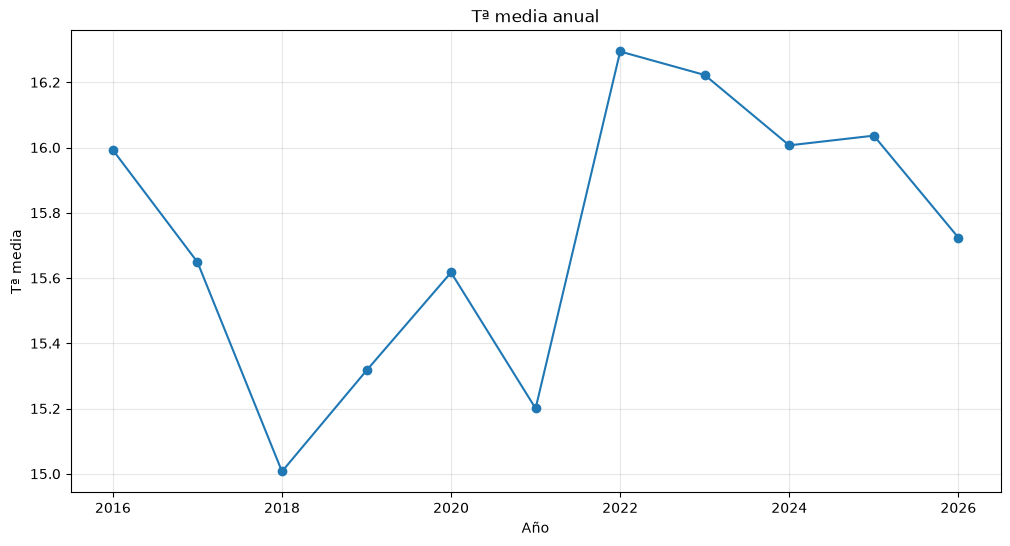

Aumento tª anual: 0.0518 °C/año, p-valor: 0.2159


In [ ]:
# Como curiosidad

media_t_anual = df_limpio.groupby(df_limpio["fecha"].dt.year)["tmed"].mean()

plt.figure(figsize=(12, 6))
plt.plot(media_t_anual.index, media_t_anual.values, marker="o")
plt.title("Tª media anual")
plt.xlabel("Año")
plt.ylabel("Tª media")
plt.grid(alpha=0.3)
plt.show()

pendiente, intercepto, r_value, p_value, std_err = stats.linregress(
    media_t_anual.index, media_t_anual.values
)
print(f"Aumento tª anual: {pendiente:.4f} °C/año, p-value: {p_value:.4f}")

# Modelado

! AÑADIR IMPORTS DEL MODELO A requirements

In [20]:
WINDOW_SIZE: int = 20

df["dia_sin"] = np.sin(2 * np.pi * df["fecha"].dt.dayofyear / 365)
df["dia_cos"] = np.cos(2 * np.pi * df["fecha"].dt.dayofyear / 365)

temp = df[df["indicativo"] == "7250C"].sort_values(by="fecha")[[
    "fecha", "tmed", "hrMedia", "dia_sin", "dia_cos"
]].reset_index(drop=True)

train = temp.iloc[10:-365]
test = temp.iloc[-365:]

rows = []
for i in range(train.shape[0] - WINDOW_SIZE):
    date = temp.iloc[i + WINDOW_SIZE]["fecha"]
    hrMedia = temp.iloc[i + WINDOW_SIZE]["hrMedia"]
    day_sin = temp.iloc[i + WINDOW_SIZE]["dia_sin"]
    day_cos = temp.iloc[i + WINDOW_SIZE]["dia_cos"]
    days = temp["tmed"].loc[i:WINDOW_SIZE + i].to_numpy()

    final_row = np.hstack([date, day_sin, day_cos, hrMedia, days])
    rows.append(final_row)

estacion_1 = pd.DataFrame(rows)
estacion_1 = estacion_1.dropna()

estacion_1_X = estacion_1.iloc[:, 1:-1]
estacion_1_Y = estacion_1.iloc[:, -1]

corte = 365
estacion_1_X_train = estacion_1_X.iloc[:-corte]
estacion_1_X_test = estacion_1_X.iloc[-corte:]
estacion_1_Y_train = estacion_1_Y.iloc[:-corte]
estacion_1_Y_test = estacion_1_Y.iloc[-corte:]

modelo = lgb.LGBMRegressor(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    min_child_samples=10,
    random_state=42,
    n_jobs=-1
)

modelo.fit(estacion_1_X_train, estacion_1_Y_train)
pred = modelo.predict(estacion_1_X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5282
[LightGBM] [Info] Number of data points in the train set: 2828, number of used features: 23
[LightGBM] [Info] Start training from score 18.569908
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [21]:
print("MAE :", mean_absolute_error(estacion_1_Y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(estacion_1_Y_test, pred)))
print("R²  :", r2_score(estacion_1_Y_test, pred))

MAE : 1.2723957673716975
RMSE: 1.6746804105576698
R²  : 0.9290712744167074


R² = 0.92 (92% de la varianza)
MAE= 1.27°C (error medio)

* Resultados muy parecidos al modelos de Random Forest: 

MAE : 1.289828911955962
RMSE: 1.7079333857785721
R²  : 0.926226543447013

Pero con menor tiempo de entrenamiento y predicción.

* Ajustamos max_depth a y n_estimators para ver cambios.

In [52]:
temp.head(5)

,fecha,tmed,hrMedia,dia_sin,dia_cos
0,2016-08-08,25.0,46.0,-0.615285,-0.788305
1,2016-08-09,24.6,44.0,-0.628763,-0.777597
2,2016-08-10,24.4,68.0,-0.642055,-0.766659
3,2016-08-11,25.3,61.0,-0.655156,-0.755493
4,2016-08-12,23.4,59.0,-0.668064,-0.744104


In [24]:
df_limpio["dia_sin"] = np.sin(2 * np.pi * df_limpio["fecha"].dt.dayofyear / 365)
df_limpio["dia_cos"] = np.cos(2 * np.pi * df_limpio["fecha"].dt.dayofyear / 365)

Definimos la funcion para entrenar los modelos

In [ ]:
#No podrá calcular tª de mañana si notiene datos de humedad de mañana...

In [29]:
def entrenar_modelo_estacion(df, indicativo, window_size=20, corte=365, min_train=1500):
    temp = df[df["indicativo"] == indicativo].sort_values(by="fecha")[[
        "fecha", "tmed", "hrMedia", "prec", "dia_sin", "dia_cos"
    ]].reset_index(drop=True)

    if len(temp) < window_size + corte + 10:
        return None

    train = temp.iloc[10:-corte]

    rows = []
    for i in range(train.shape[0] - window_size):
        date = temp.iloc[i + window_size]["fecha"]
        day_sin = temp.iloc[i + window_size]["dia_sin"]
        day_cos = temp.iloc[i + window_size]["dia_cos"]
        hrMedia_ayer = temp.iloc[i + window_size - 1]["hrMedia"]
        prec_ayer = temp.iloc[i + window_size - 1]["prec"]
        days = temp["tmed"].loc[i:window_size + i].to_numpy()
        rows.append(np.hstack([date, day_sin, day_cos, hrMedia_ayer, prec_ayer, days]))

    datos = pd.DataFrame(rows).dropna()
    if len(datos) < corte + 50:
        return None

    X = datos.iloc[:, 1:-1]
    y = datos.iloc[:, -1]

    X_train, X_test = X.iloc[:-corte], X.iloc[-corte:]
    y_train, y_test = y.iloc[:-corte], y.iloc[-corte:]

    if len(X_train) < min_train:
        return None

    modelo = lgb.LGBMRegressor(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        min_child_samples=10,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    modelo.fit(
        X_train, y_train,
        eval_X=X_test, eval_y=y_test,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    pred = modelo.predict(X_test)
    metricas = {
        "indicativo": indicativo,
        "mae": mean_absolute_error(y_test, pred),
        "rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "r2": r2_score(y_test, pred),
        "n_train": len(X_train)
    }

    return modelo, metricas

In [30]:
os.makedirs("modelos", exist_ok=True)

# Probamos con 10 estaciones
resultados = []
est_probar = df_limpio["indicativo"].unique()[:10]

for indicativo in est_probar:
    resultado = entrenar_modelo_estacion(df_limpio, indicativo)
    if resultado is None:
        print(f"{indicativo}: datos insuficientes")
        continue

    modelo, metricas = resultado
    modelo.booster_.save_model(f"modelos/{indicativo}.txt")
    resultados.append(metricas)

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

0255B: datos insuficientes
  indicativo       mae      rmse        r2  n_train
0      7250C  1.306308  1.718899  0.925245     2867
1      5612B  1.446961  1.908556  0.910715     2519
2      2885K  1.622917  2.032339  0.913579     2581
3      8492X  1.403720  1.803678  0.927944     2820
4      2182C  1.723492  2.144248  0.919687     2775
5      8270X  1.362576  1.758674  0.928309     2718
6      4520X  1.377823  1.754173  0.923248     2821
7      2918Y  1.697422  2.157870  0.899870     2698
8      2400E  1.686915  2.110650  0.906042     2482


In [ ]:
#   indicativo       mae      rmse        r2      n_train
#      7250C      1.306308  1.718899   0.925245     2867
# Mejores metricas sin prec_ayer? 
#Comprobar y reajustar

<Axes: xlabel='n_train', ylabel='mae'>

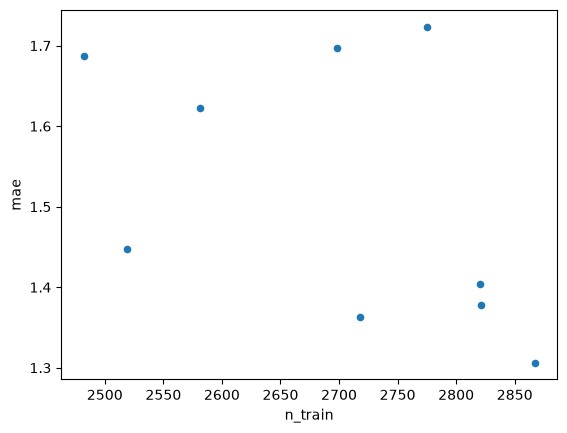

In [31]:
df_resultados.plot.scatter(x="n_train", y="mae")

In [ ]:
# Estaciones con menos datos. Cambio min_train=1500 en la funcion

In [32]:
temp[temp.isna().any(axis=1)]

,fecha,tmed,hrMedia,dia_sin,dia_cos
282,2017-05-17,NaN,NaN,0.705584,-0.708627
2379,2023-02-12,9.5,NaN,0.674444,0.738326
2380,2023-02-13,NaN,NaN,0.687053,0.726608
2387,2023-02-20,NaN,73.0,0.769415,0.638749
3609,2026-06-26,NaN,NaN,0.094537,-0.995521
3610,2026-06-27,NaN,NaN,0.077386,-0.997001
3611,2026-06-28,NaN,NaN,0.060213,-0.998186
3612,2026-06-29,NaN,NaN,0.043022,-0.999074


In [ ]:
# NO EJECUTAR
#  Si se reentrena revisar rutas
os.makedirs("modelos", exist_ok=True)

resultados = []
errores = []

todas_las_estaciones = df_limpio["indicativo"].unique()

for idx, indicativo in enumerate(todas_las_estaciones):
    if idx % 50 == 0:
        print(f"Procesando {idx}/{len(todas_las_estaciones)}...")

    try:
        resultado = entrenar_modelo_estacion(df_limpio, indicativo, min_train=1500)
    except Exception as e:
        errores.append({"indicativo": indicativo, "error": str(e)})
        continue

    if resultado is None:
        continue

    modelo, metricas = resultado
    modelo.booster_.save_model(f"modelos/{indicativo}.txt")
    resultados.append(metricas)

df_resultados = pd.DataFrame(resultados)
df_errores = pd.DataFrame(errores)

print(f"Modelos entrenados: {len(df_resultados)} de {len(todas_las_estaciones)}")
print(f"Estaciones con error: {len(df_errores)}")

Procesando 0/880...
Procesando 50/880...
Procesando 100/880...
Procesando 150/880...
Procesando 200/880...
Procesando 250/880...
Procesando 300/880...
Procesando 350/880...
Procesando 400/880...
Procesando 450/880...
Procesando 500/880...
Procesando 550/880...
Procesando 600/880...
Procesando 650/880...
Procesando 700/880...
Procesando 750/880...
Procesando 800/880...
Procesando 850/880...
Modelos entrenados: 807 de 880
Estaciones con error: 0


In [36]:
df_resultados.describe()


,mae,rmse,r2,n_train
count,807.000000,807.000000,807.000000,807.000000
mean,1.412614,1.807983,0.902566,2671.726146
std,0.282508,0.333629,0.046599,266.758840
min,0.470979,0.676169,0.661855,1503.000000
25%,1.277493,1.653389,0.872614,2620.000000
50%,1.449110,1.849214,0.920248,2777.000000
75%,1.623030,2.052727,0.937197,2835.000000
max,2.062979,2.544827,0.962661,2878.000000


In [ ]:
#  Si se reentrena revisar rutas
print(os.getcwd())

c:\Users\Kirsay\Desktop\AEMET_proyecto_local\zona_de_trabajo
